<a href="https://colab.research.google.com/github/Md-Golam-Raiyhan/INSE-6450-Smart-Grocery-Assistant/blob/main/continual_hitl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [4]:
pantry = pd.read_csv("data/pantry.csv")
consumption = pd.read_csv("data/consumption_log.csv")
recipes = pd.read_csv("data/recipes.csv")
user = pd.read_csv("data/user_profile.csv")

print("Loaded:")
print("pantry:", pantry.shape)
print("consumption:", consumption.shape)
print("recipes:", recipes.shape)
print("user:", user.shape)

Loaded:
pantry: (15, 6)
consumption: (90, 4)
recipes: (10, 7)
user: (1, 5)


In [5]:
items_meta = pantry.set_index("item_id")[["unit", "essential", "quantity"]]

pivot = consumption.pivot_table(index="week", columns="item_id", values="quantity_used")

samples = []
weeks = sorted(pivot.index.tolist())

for t in weeks:
    if t < 3:
        continue
    for item_id in pivot.columns:
        y = float(pivot.loc[t, item_id])
        last1 = float(pivot.loc[t-1, item_id])
        last2 = float(pivot.loc[t-2, item_id])
        roll2 = (last1 + last2) / 2.0

        unit = items_meta.loc[item_id, "unit"]
        is_piece = 1.0 if unit == "piece" else 0.0
        essential = float(items_meta.loc[item_id, "essential"])
        pantry_qty = float(items_meta.loc[item_id, "quantity"])

        samples.append({
            "t": t,
            "item_id": int(item_id),
            "last1": last1,
            "last2": last2,
            "roll2": roll2,
            "is_piece": is_piece,
            "essential": essential,
            "pantry_qty": pantry_qty,
            "y": y
        })

df = pd.DataFrame(samples)
display(df.head())
print("Supervised samples:", df.shape)

,t,item_id,last1,last2,roll2,is_piece,essential,pantry_qty,y
0,3,1,0.90,0.97,0.935,0.0,1.0,5.0,0.95
1,3,2,4.00,4.00,4.000,1.0,1.0,12.0,6.00
2,3,3,1.01,1.18,1.095,0.0,1.0,2.0,1.08
3,3,4,0.85,0.63,0.740,0.0,0.0,1.5,0.47
4,3,5,7.00,1.00,4.000,1.0,1.0,6.0,3.00


Supervised samples: (60, 9)


In [6]:
train_df = df[df["t"].isin([3, 4])].copy()
val_df   = df[df["t"] == 5].copy()
test_df  = df[df["t"] == 6].copy()

FEATURES = ["last1", "last2", "roll2", "is_piece", "essential", "pantry_qty"]

print(train_df.shape, val_df.shape, test_df.shape)

(30, 9) (15, 9) (15, 9)


In [7]:
def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

class ForecastDS(torch.utils.data.Dataset):
    def __init__(self, frame, features):
        self.x = torch.tensor(frame[features].values, dtype=torch.float32)
        self.y = torch.tensor(frame["y"].values, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

class GlobalLinear(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, 1)

    def forward(self, x):
        return self.lin(x)

def train_model(train_loader, val_loader, in_dim, lr=0.01, weight_decay=1e-4, epochs=50):
    model = GlobalLinear(in_dim).to(device)
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val = float("inf")

    start = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_losses.append(loss_fn(pred, yb).item())

        val_loss = float(np.mean(val_losses))
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    train_time = time.perf_counter() - start
    return model, train_time

def predict(model, frame, features):
    X = torch.tensor(frame[features].values, dtype=torch.float32).to(device)
    with torch.no_grad():
        pred = model(X).cpu().numpy().reshape(-1)
    return pred

In [8]:
train_ds = ForecastDS(train_df, FEATURES)
val_ds = ForecastDS(val_df, FEATURES)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

base_model, base_train_time = train_model(train_loader, val_loader, in_dim=len(FEATURES))

base_pred = predict(base_model, test_df, FEATURES)
base_metrics = eval_metrics(test_df["y"], base_pred)
print("Base test metrics:", base_metrics)

Base test metrics: (1.1728679343859352, 1.513778068210665, 0.5175180877488964)


In [9]:
# Simulate multiple drift windows from test data
windows = []
drift_factors = [1.0, 1.1, 1.2, 1.3]

for i, factor in enumerate(drift_factors):
    w = test_df.copy()
    w["last1"] *= factor
    w["last2"] *= factor
    w["roll2"] *= factor
    w["y"] *= factor
    w["window_id"] = i
    windows.append(w)

stream_df = pd.concat(windows, ignore_index=True)
display(stream_df.head())
print("Stream shape:", stream_df.shape)

,t,item_id,last1,last2,roll2,is_piece,essential,pantry_qty,y,window_id
0,6,1,1.01,1.15,1.080,0.0,1.0,5.0,0.77,0
1,6,2,8.00,7.00,7.500,1.0,1.0,12.0,5.00,0
2,6,3,0.98,1.23,1.105,0.0,1.0,2.0,1.38,0
3,6,4,0.72,0.61,0.665,0.0,0.0,1.5,0.59,0
4,6,5,4.00,1.00,2.500,1.0,1.0,6.0,6.00,0


Stream shape: (60, 10)


In [10]:
from collections import deque

BUFFER_SIZE = 40
replay_buffer = deque(maxlen=BUFFER_SIZE)

def add_to_buffer(frame):
    for _, row in frame.iterrows():
        replay_buffer.append(row.to_dict())

def buffer_to_df():
    if len(replay_buffer) == 0:
        return pd.DataFrame(columns=stream_df.columns)
    return pd.DataFrame(list(replay_buffer))

In [11]:
def continual_update(model, recent_df, replay_df, features, lr=0.005, epochs=30):
    update_df = pd.concat([recent_df, replay_df], ignore_index=True)
    if len(update_df) == 0:
        return model, 0.0

    train_ds = ForecastDS(update_df, features)
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    model.train()
    start = time.perf_counter()

    for _ in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    update_time = time.perf_counter() - start
    return model, update_time

In [12]:
def confidence_score(frame, preds):
    baseline = frame["roll2"].values
    conf = 1.0 / (1.0 + np.abs(preds - baseline))
    return conf

def query_most_uncertain(frame, preds, budget_frac=0.2):
    conf = confidence_score(frame, preds)
    frame = frame.copy()
    frame["confidence"] = conf
    frame = frame.sort_values("confidence", ascending=True)

    k = max(1, int(len(frame) * budget_frac))
    return frame.head(k)

In [13]:
cl_results = []
model_cl = GlobalLinear(len(FEATURES)).to(device)
model_cl.load_state_dict(base_model.state_dict())

for wid in sorted(stream_df["window_id"].unique()):
    w = stream_df[stream_df["window_id"] == wid].copy()

    # Before update
    pred_before = predict(model_cl, w, FEATURES)
    metrics_before = eval_metrics(w["y"], pred_before)

    # Simulated human/AL selection
    queried = query_most_uncertain(w, pred_before, budget_frac=0.2)

    # Replay + update
    replay_df = buffer_to_df()
    model_cl, update_time = continual_update(model_cl, queried, replay_df, FEATURES, lr=0.005, epochs=30)

    # After update
    pred_after = predict(model_cl, w, FEATURES)
    metrics_after = eval_metrics(w["y"], pred_after)

    add_to_buffer(queried)

    cl_results.append({
        "window": wid,
        "mae_before": metrics_before[0],
        "rmse_before": metrics_before[1],
        "r2_before": metrics_before[2],
        "mae_after": metrics_after[0],
        "rmse_after": metrics_after[1],
        "r2_after": metrics_after[2],
        "update_time_s": update_time,
        "queried_samples": len(queried)
    })

cl_df = pd.DataFrame(cl_results)
display(cl_df)
cl_df.to_csv("outputs/continual_learning_results.csv", index=False)

/tmp/ipykernel_1262/3573360387.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  update_df = pd.concat([recent_df, replay_df], ignore_index=True)


,window,mae_before,rmse_before,r2_before,mae_after,rmse_after,r2_after,update_time_s,queried_samples
0,0,1.172868,1.513778,0.517518,0.953055,1.282668,0.653594,0.039519,3
1,1,1.088559,1.454958,0.631640,0.963405,1.326080,0.694008,0.034183,3
2,2,1.103659,1.572835,0.638290,1.077463,1.474055,0.682297,0.030986,3
3,3,1.383804,1.774917,0.607512,1.301706,1.712152,0.634780,0.026526,3


In [14]:
cl_results = []
model_cl = GlobalLinear(len(FEATURES)).to(device)
model_cl.load_state_dict(base_model.state_dict())

for wid in sorted(stream_df["window_id"].unique()):
    w = stream_df[stream_df["window_id"] == wid].copy()

    # Before update
    pred_before = predict(model_cl, w, FEATURES)
    metrics_before = eval_metrics(w["y"], pred_before)

    # Simulated human/AL selection
    queried = query_most_uncertain(w, pred_before, budget_frac=0.2)

    # Replay + update
    replay_df = buffer_to_df()
    model_cl, update_time = continual_update(model_cl, queried, replay_df, FEATURES, lr=0.005, epochs=30)

    # After update
    pred_after = predict(model_cl, w, FEATURES)
    metrics_after = eval_metrics(w["y"], pred_after)

    add_to_buffer(queried)

    cl_results.append({
        "window": wid,
        "mae_before": metrics_before[0],
        "rmse_before": metrics_before[1],
        "r2_before": metrics_before[2],
        "mae_after": metrics_after[0],
        "rmse_after": metrics_after[1],
        "r2_after": metrics_after[2],
        "update_time_s": update_time,
        "queried_samples": len(queried)
    })

cl_df = pd.DataFrame(cl_results)
display(cl_df)
cl_df.to_csv("outputs/continual_learning_results.csv", index=False)

,window,mae_before,rmse_before,r2_before,mae_after,rmse_after,r2_after,update_time_s,queried_samples
0,0,1.172868,1.513778,0.517518,1.098707,1.416606,0.577472,0.033248,3
1,1,1.243814,1.622202,0.542089,1.033541,1.424439,0.646931,0.051966,3
2,2,1.183912,1.657447,0.598326,1.072529,1.548206,0.649529,0.046871,3
3,3,1.308413,1.821861,0.586476,1.247169,1.701137,0.639464,0.051579,3


In [15]:
continual_update_efficiency = pd.DataFrame({
    "window": cl_df["window"],
    "update_time_s": cl_df["update_time_s"],
    "queried_samples": cl_df["queried_samples"]
})

display(continual_update_efficiency)
continual_update_efficiency.to_csv("outputs/continual_update_efficiency.csv", index=False)

print("✅ Saved: outputs/continual_update_efficiency.csv")

,window,update_time_s,queried_samples
0,0,0.033248,3
1,1,0.051966,3
2,2,0.046871,3
3,3,0.051579,3


✅ Saved: outputs/continual_update_efficiency.csv


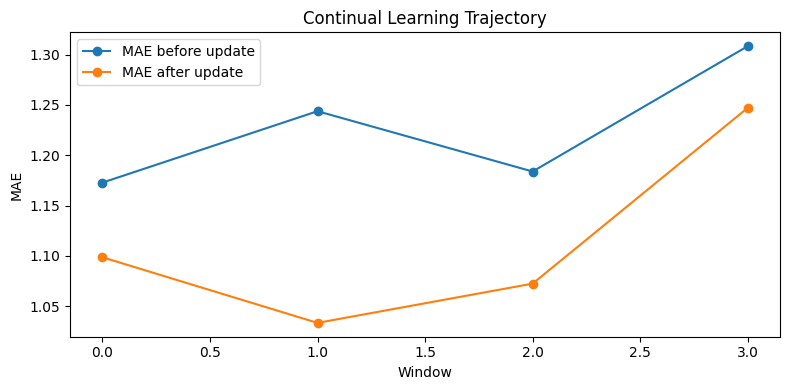

In [16]:
plt.figure(figsize=(8,4))
plt.plot(cl_df["window"], cl_df["mae_before"], marker="o", label="MAE before update")
plt.plot(cl_df["window"], cl_df["mae_after"], marker="o", label="MAE after update")
plt.xlabel("Window")
plt.ylabel("MAE")
plt.title("Continual Learning Trajectory")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/continual_learning_trajectory.png")
plt.show()

In [17]:
labeling_burden = pd.DataFrame({
    "window": cl_df["window"],
    "samples_in_window": [len(stream_df[stream_df["window_id"] == w]) for w in cl_df["window"]],
    "queried_samples": cl_df["queried_samples"]
})
labeling_burden["reduction_pct"] = 100 * (1 - labeling_burden["queried_samples"] / labeling_burden["samples_in_window"])

display(labeling_burden)
labeling_burden.to_csv("outputs/labeling_burden_summary.csv", index=False)

,window,samples_in_window,queried_samples,reduction_pct
0,0,15,3,80.0
1,1,15,3,80.0
2,2,15,3,80.0
3,3,15,3,80.0


In [18]:
active_learning_results = cl_df[[
    "window",
    "mae_before", "rmse_before", "r2_before",
    "mae_after", "rmse_after", "r2_after",
    "queried_samples"
]].copy()

display(active_learning_results)
active_learning_results.to_csv("outputs/active_learning_results.csv", index=False)

print("✅ Saved: outputs/active_learning_results.csv")

,window,mae_before,rmse_before,r2_before,mae_after,rmse_after,r2_after,queried_samples
0,0,1.172868,1.513778,0.517518,1.098707,1.416606,0.577472,3
1,1,1.243814,1.622202,0.542089,1.033541,1.424439,0.646931,3
2,2,1.183912,1.657447,0.598326,1.072529,1.548206,0.649529,3
3,3,1.308413,1.821861,0.586476,1.247169,1.701137,0.639464,3


✅ Saved: outputs/active_learning_results.csv


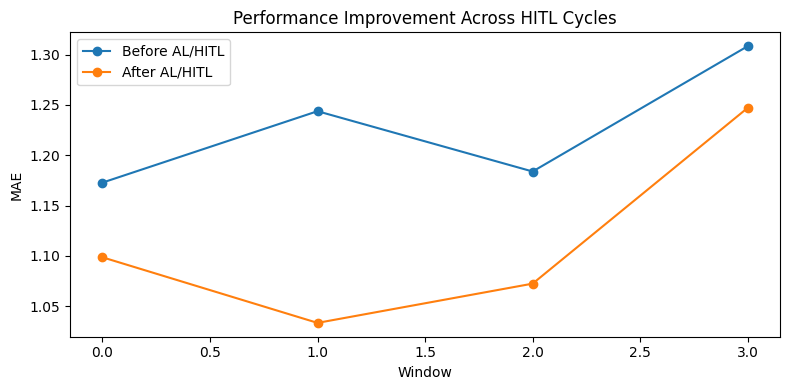

In [19]:
plt.figure(figsize=(8,4))
plt.plot(cl_df["window"], cl_df["mae_before"], marker="o", label="Before AL/HITL")
plt.plot(cl_df["window"], cl_df["mae_after"], marker="o", label="After AL/HITL")
plt.xlabel("Window")
plt.ylabel("MAE")
plt.title("Performance Improvement Across HITL Cycles")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/active_learning_performance_curve.png")
plt.show()

In [20]:
def latency_benchmark(model, frame, features, n_runs=200):
    X = frame[features].values.astype(np.float32)
    times = []
    model.eval()
    with torch.no_grad():
        for _ in range(n_runs):
            idx = np.random.randint(0, len(X))
            xb = torch.tensor(X[idx:idx+1], dtype=torch.float32).to(device)
            t0 = time.perf_counter()
            _ = model(xb)
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000.0)

    times = sorted(times)
    p50 = times[int(0.5 * len(times))]
    p90 = times[int(0.9 * len(times))]
    thr = 1000.0 / float(np.mean(times))
    return p50, p90, thr

p50, p90, thr = latency_benchmark(model_cl, test_df, FEATURES)
param_count = sum(p.numel() for p in model_cl.parameters())

torch.save(model_cl.state_dict(), "outputs/milestone4_final_model.pt")
size_kb = os.path.getsize("outputs/milestone4_final_model.pt") / 1024.0

eff_df = pd.DataFrame([{
    "train_time_s": base_train_time,
    "avg_update_time_s": cl_df["update_time_s"].mean(),
    "p50_ms": p50,
    "p90_ms": p90,
    "throughput": thr,
    "params": param_count,
    "model_size_kb": size_kb
}])

display(eff_df)
eff_df.to_csv("outputs/final_efficiency_summary.csv", index=False)

,train_time_s,avg_update_time_s,p50_ms,p90_ms,throughput,params,model_size_kb
0,0.289329,0.045916,0.015128,0.028303,45897.761358,7,2.09082


In [21]:
final_results = pd.DataFrame([
    {"scenario": "clean_base", "MAE": base_metrics[0], "RMSE": base_metrics[1], "R2": base_metrics[2]},
    {"scenario": "continual_learning_last_window_after", "MAE": cl_df.iloc[-1]["mae_after"], "RMSE": cl_df.iloc[-1]["rmse_after"], "R2": cl_df.iloc[-1]["r2_after"]},
])

display(final_results)
final_results.to_csv("outputs/final_system_results.csv", index=False)

,scenario,MAE,RMSE,R2
0,clean_base,1.172868,1.513778,0.517518
1,continual_learning_last_window_after,1.247169,1.701137,0.639464


In [22]:
project_summary = pd.DataFrame([
    {"Milestone": 1, "Main Result": "Data design and exploration completed"},
    {"Milestone": 2, "Main Result": "Restock predictor trained with CPU-efficient linear PyTorch model"},
    {"Milestone": 3, "Main Result": "Robustness, monitoring, and adaptation pipeline implemented"},
    {"Milestone": 4, "Main Result": "Continual learning and HITL integrated into complete AI system"},
])

display(project_summary)
project_summary.to_csv("outputs/project_summary_table.csv", index=False)

,Milestone,Main Result
0,1,Data design and exploration completed
1,2,Restock predictor trained with CPU-efficient l...
2,3,"Robustness, monitoring, and adaptation pipelin..."
3,4,Continual learning and HITL integrated into co...
